/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/aishvarya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = no

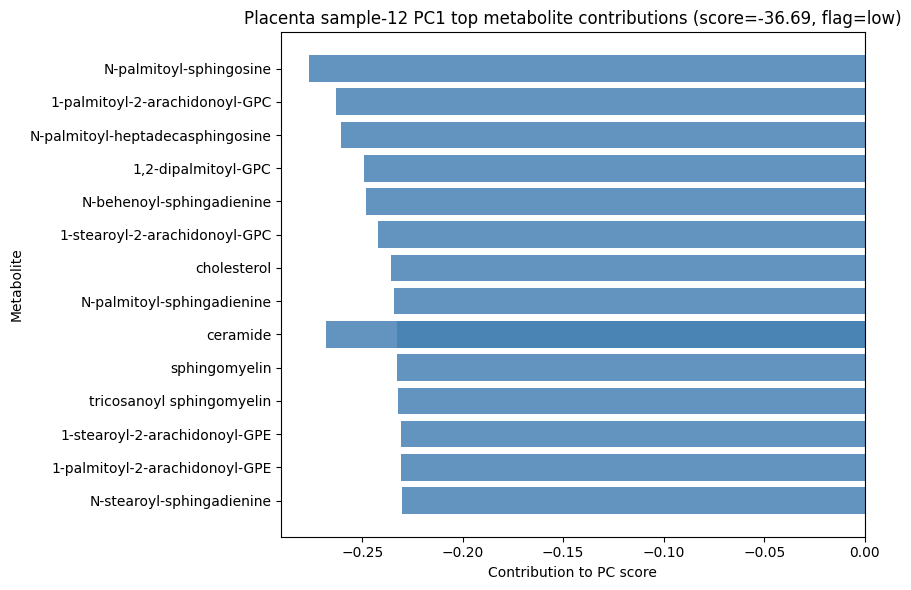

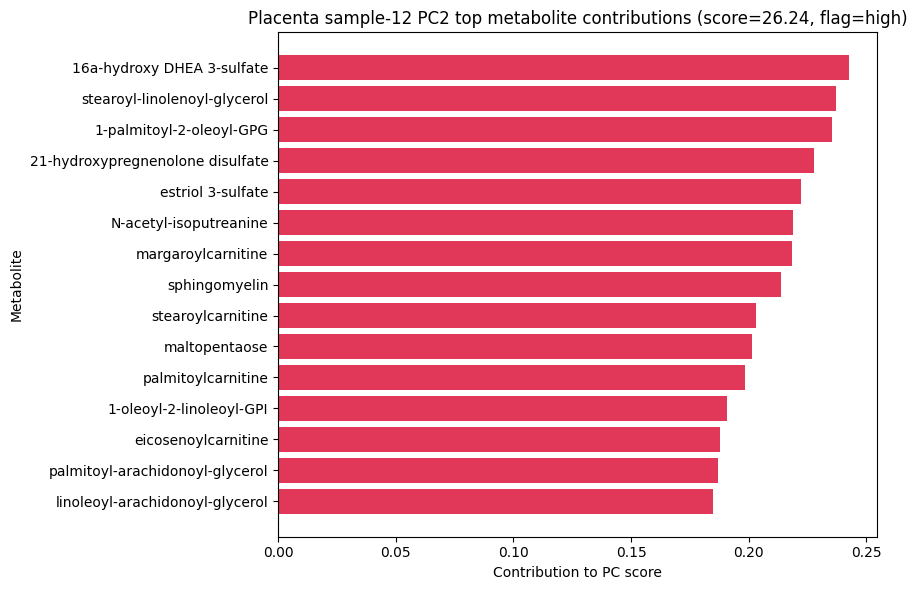

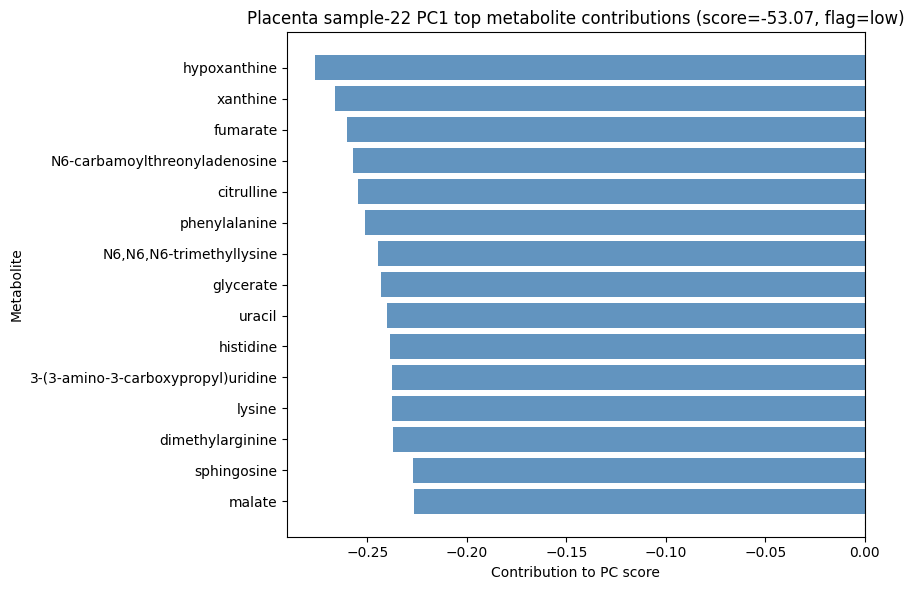

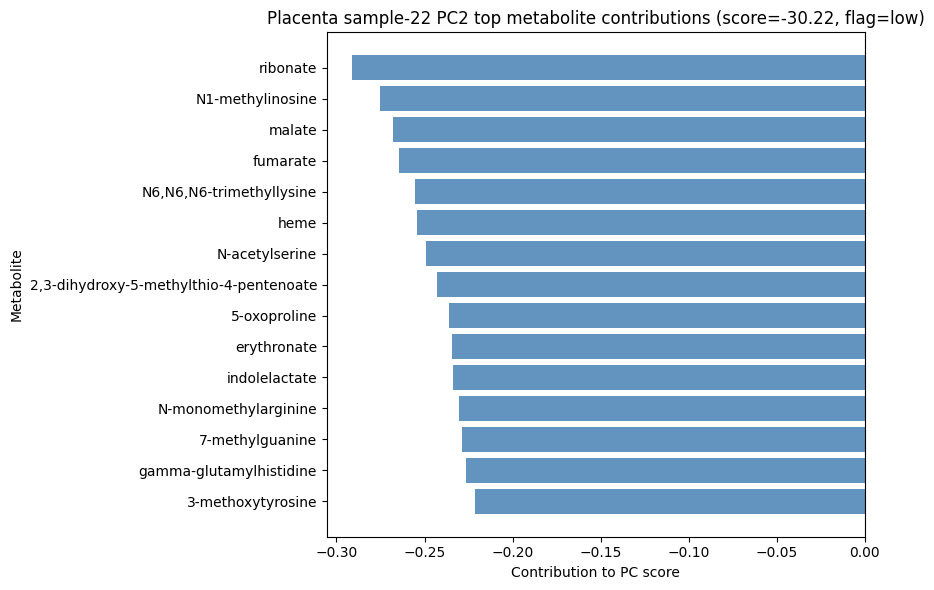

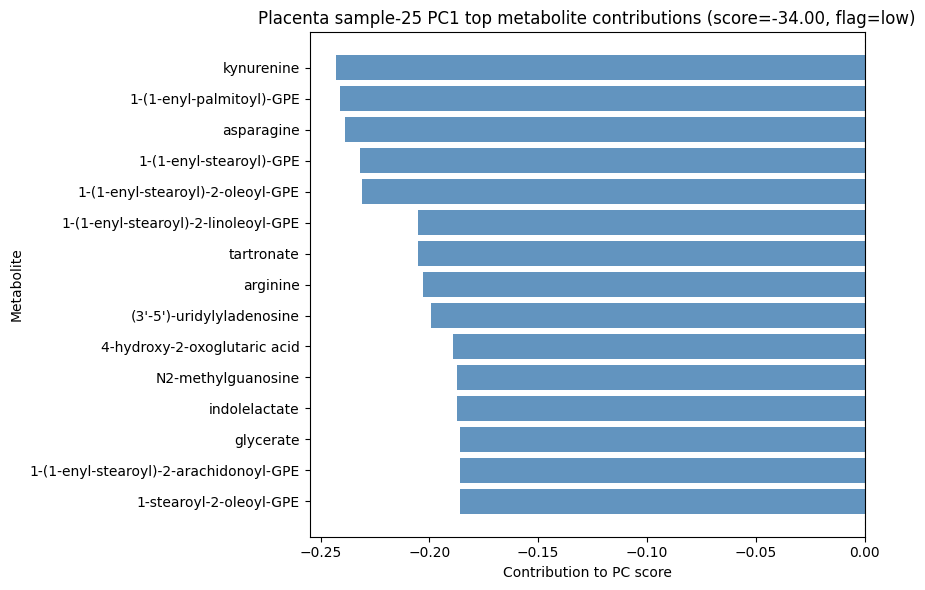

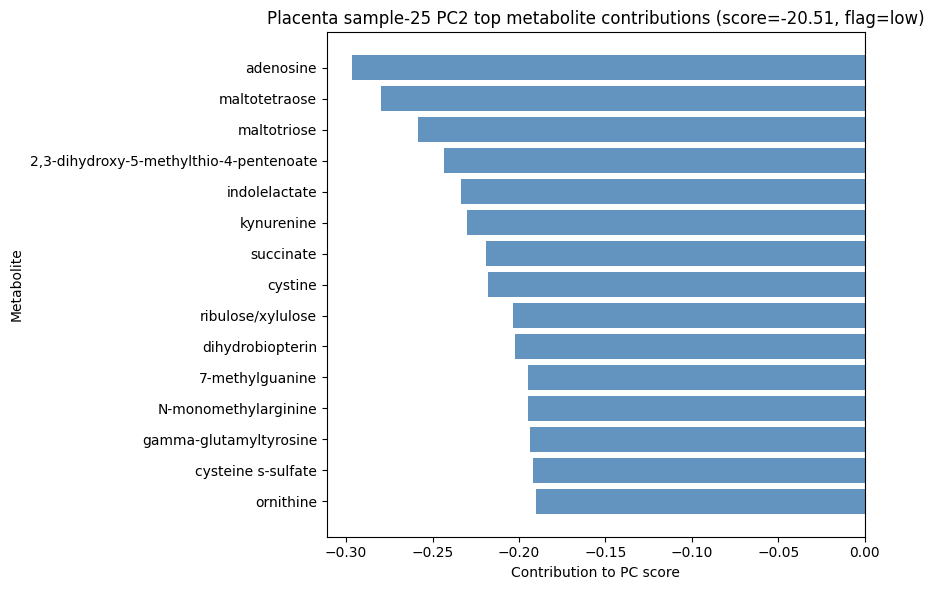

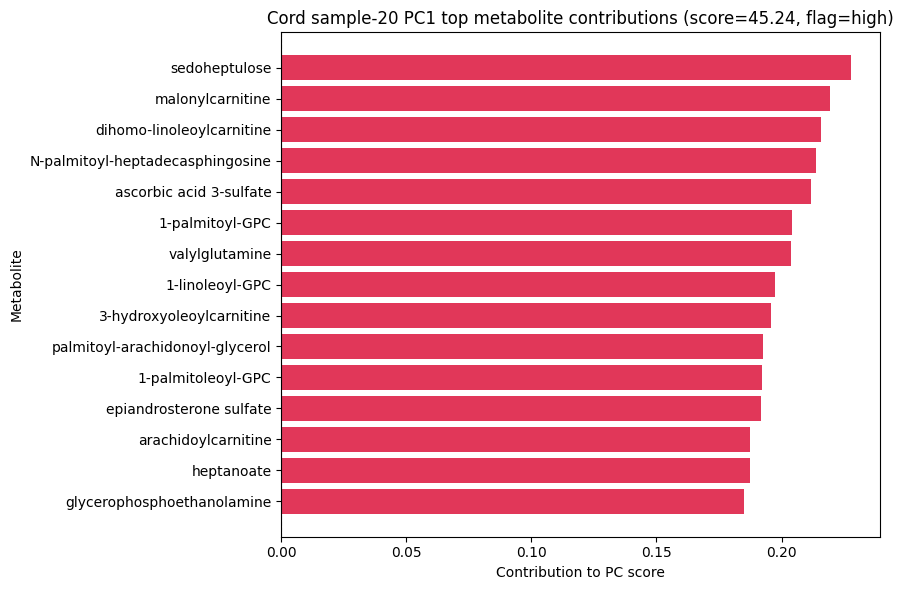

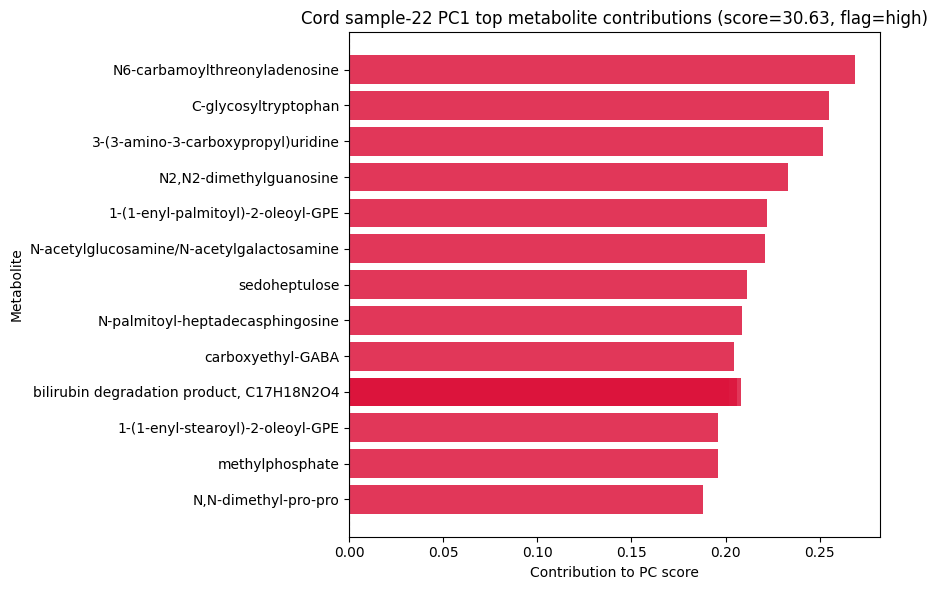

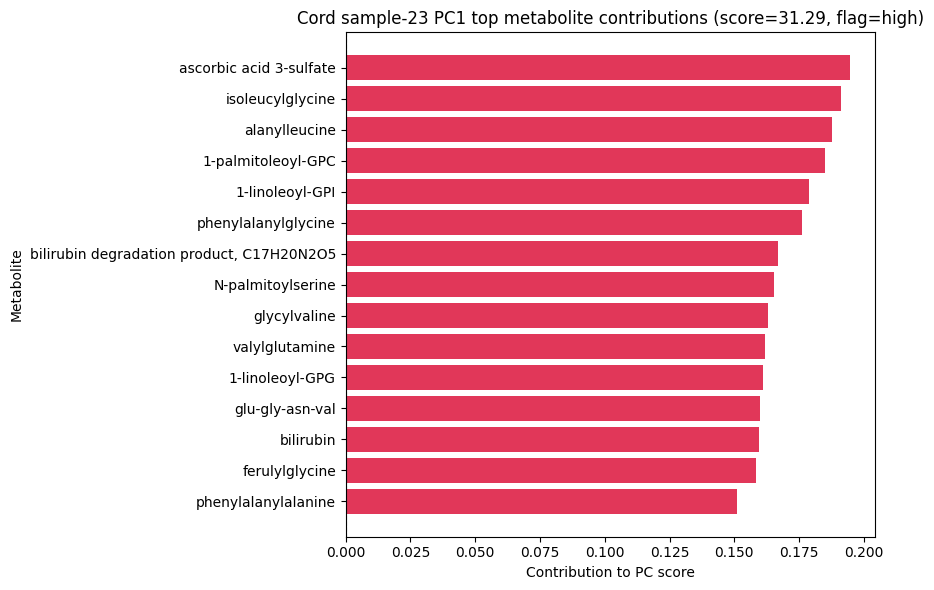

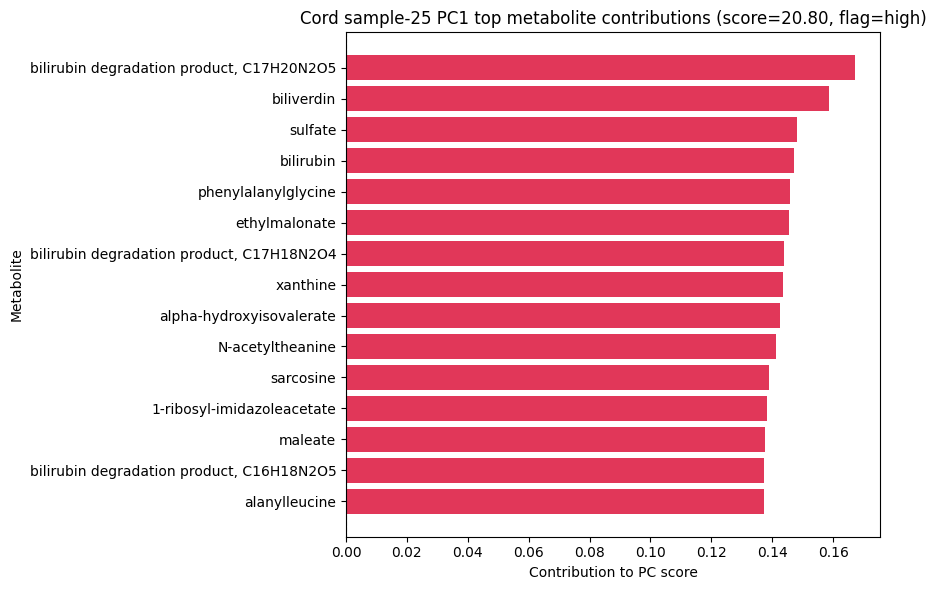

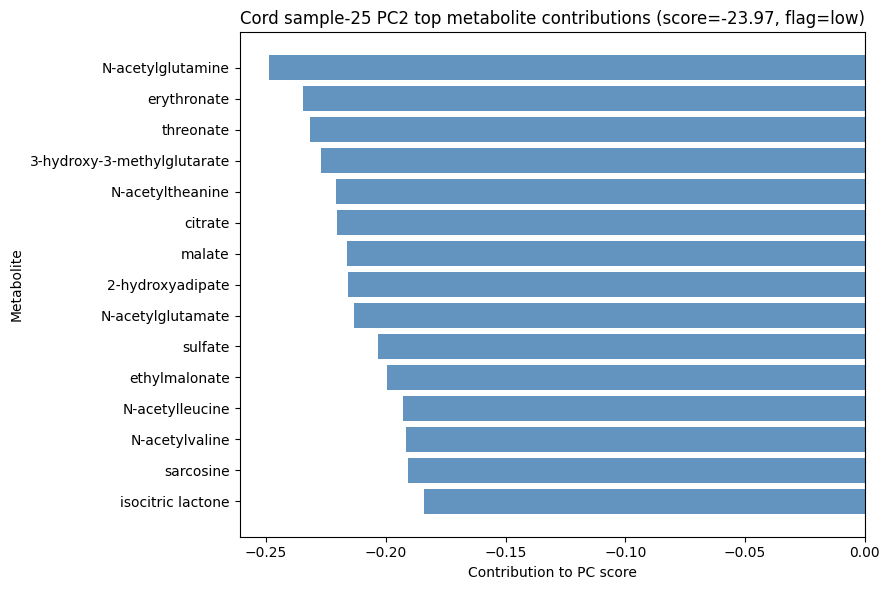

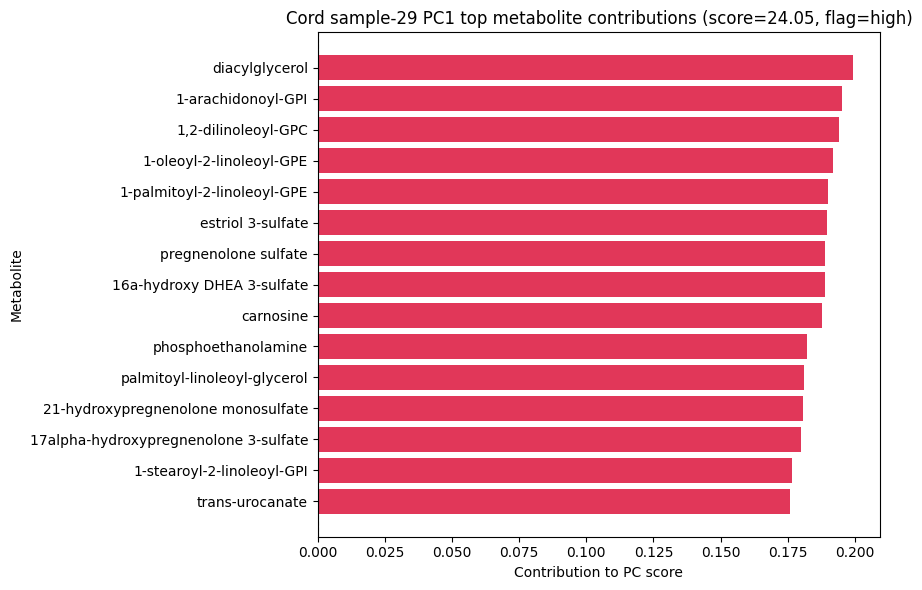

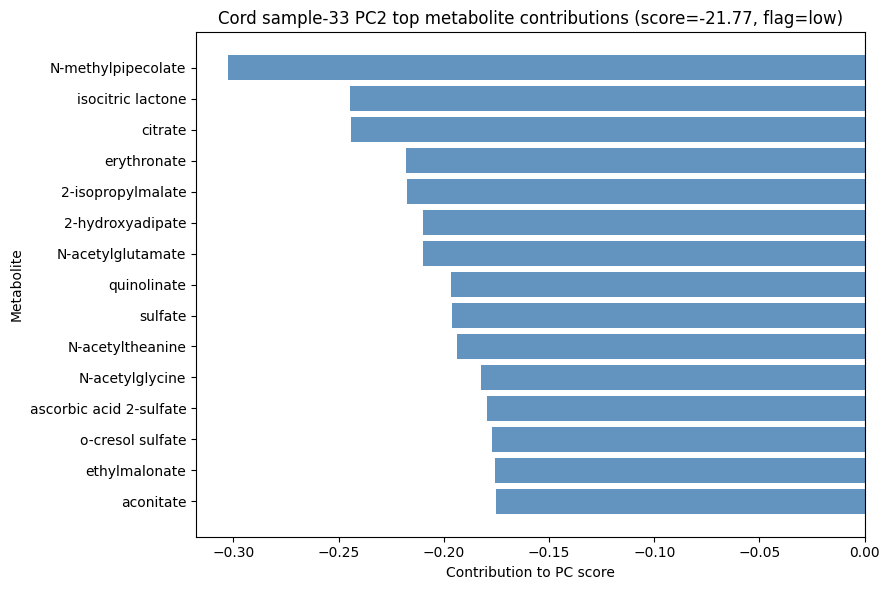

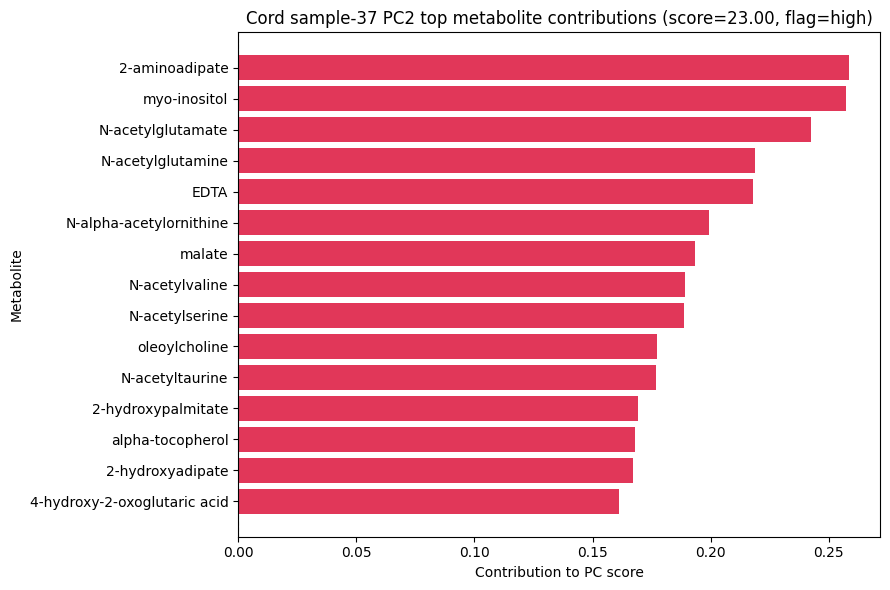


Saved CSV files:
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/placenta_top_loadings_pc1_pc2.csv
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/cord_top_loadings_pc1_pc2.csv
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/placenta_outlier_contributions.csv
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/cord_outlier_contributions.csv
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/combine

,Dataset,PC,Metabolite,Metabolite_Name,Outlier_Count,Mean_Abs_Contribution,Mean_Contribution,Mean_Abs_Z,Mean_Abs_Loading,Typical_Value_Direction,Typical_Loading_Direction
75,Cord,PC1,902001,alanylleucine,3,0.168471,0.168471,3.085379,0.054603,high,positive
73,Cord,PC1,801007,"bilirubin degradation product, C17H18N2O4 (3)**",3,0.166633,0.166633,2.734627,0.060934,low,negative
80,Cord,PC1,902025,valylglutamine,3,0.166122,0.166122,2.648803,0.062716,high,positive
72,Cord,PC1,801006,"bilirubin degradation product, C17H18N2O4 (2)**",3,0.162665,0.162665,2.655740,0.061250,low,negative
19,Cord,PC1,210012,sedoheptulose,2,0.219644,0.219644,3.470625,0.063287,high,positive
26,Cord,PC1,604011,N-palmitoyl-heptadecasphingosine (d17:1/16:0)*,2,0.211309,0.211309,3.807565,0.055497,high,positive
20,Cord,PC1,301004,ascorbic acid 3-sulfate*,2,0.203284,0.203284,3.167960,0.064169,low,negative
27,Cord,PC1,607001,"diacylglycerol (16:1/18:2 [2], 16:0/18:3 [1])*",2,0.190251,0.190251,4.138676,0.045969,high,positive
43,Cord,PC1,642024,1-palmitoleoyl-GPC (16:1)*,2,0.188520,0.188520,3.456957,0.054534,low,negative
74,Cord,PC1,801009,"bilirubin degradation product, C17H20N2O5 (2)**",2,0.167030,0.167030,2.718526,0.061441,low,negative


In [16]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))

from src.utils.config import (
    PCA_CSV_DIR,
    OUTPUTS_DIR,
    PLACENTA_DATA_T,
    CORD_DATA_T,
)

OUTLIER_CSV_DIR = os.path.join(PCA_CSV_DIR, "05_outliers")
OUTLIER_LOADINGS_CSV_DIR = os.path.join(PCA_CSV_DIR, "07_outlier_loadings")
OUTLIER_LOADINGS_IMG_DIR = os.path.join(OUTPUTS_DIR, "output_images", "07_outlier_loadings")

os.makedirs(OUTLIER_LOADINGS_CSV_DIR, exist_ok=True)
os.makedirs(OUTLIER_LOADINGS_IMG_DIR, exist_ok=True)

placenta_flags_path = os.path.join(OUTLIER_CSV_DIR, "placenta_outlier_flags_all_samples.csv")
cord_flags_path = os.path.join(OUTLIER_CSV_DIR, "cord_outlier_flags_all_samples.csv")

placenta_flags = pd.read_csv(placenta_flags_path, index_col="Sample")
cord_flags = pd.read_csv(cord_flags_path, index_col="Sample")

PLACENTA_ANNOTATION_PATH = str(Path(PLACENTA_DATA_T).with_name("Met_ana_placenta.csv"))
CORD_ANNOTATION_PATH = str(Path(CORD_DATA_T).with_name("Met_ana_cord.csv"))


def build_metabolite_name_map(annotation_paths):
    mapping = {}
    for annotation_path in annotation_paths:
        if not os.path.exists(annotation_path):
            print(f"Warning: annotation file not found: {annotation_path}")
            continue

        ann = pd.read_csv(annotation_path)
        if "COMP ID" not in ann.columns or "COMPOUND Name" not in ann.columns:
            print(f"Warning: expected columns not found in {annotation_path}")
            continue

        id_series = ann["COMP ID"].astype(str).str.strip()
        name_series = ann["COMPOUND Name"].astype(str).str.strip()
        valid = (
            (id_series != "")
            & (name_series != "")
            & (~id_series.str.lower().eq("nan"))
            & (~name_series.str.lower().eq("nan"))
        )

        mapping.update(dict(zip(id_series[valid], name_series[valid])))

    return mapping


metabolite_name_map = build_metabolite_name_map([PLACENTA_ANNOTATION_PATH, CORD_ANNOTATION_PATH])


def compute_outlier_loadings(data_t_path, flags_df, dataset_label, metabolite_name_map, top_n=20, n_components=10):
    matrix = pd.read_csv(data_t_path, index_col="Sample").astype(float)

    shared_samples = matrix.index.intersection(flags_df.index)
    matrix = matrix.loc[shared_samples]
    flags = flags_df.loc[shared_samples]

    if matrix.empty:
        raise ValueError(f"No overlapping samples for {dataset_label}")

    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(matrix)
    x_scaled_df = pd.DataFrame(x_scaled, index=matrix.index, columns=matrix.columns)

    n_comp = min(n_components, matrix.shape[0], matrix.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    scores = pca.fit_transform(x_scaled)

    pc_cols = [f"PC{i+1}" for i in range(scores.shape[1])]
    component_df = pd.DataFrame(pca.components_.T, index=matrix.columns, columns=pc_cols)

    # Global high-loading metabolites per PC (dataset-level view)
    loading_rows = []
    for pc in ["PC1", "PC2"]:
        if pc not in component_df.columns:
            continue
        top = component_df[pc].abs().sort_values(ascending=False).head(top_n)
        for rank, metabolite in enumerate(top.index, start=1):
            metabolite_id = str(metabolite)
            metabolite_name = metabolite_name_map.get(metabolite_id, metabolite_id)
            loading_val = component_df.loc[metabolite, pc]
            loading_rows.append(
                {
                    "Dataset": dataset_label,
                    "PC": pc,
                    "Rank": rank,
                    "Metabolite": metabolite_id,
                    "Metabolite_Name": metabolite_name,
                    "Loading": loading_val,
                    "Abs_Loading": abs(loading_val),
                    "Loading_Direction": "positive" if loading_val >= 0 else "negative",
                }
            )

    # Outlier-specific metabolite drivers (sample-level view)
    outliers = flags[flags.get("Any_outlier", False)].copy()
    contribution_rows = []

    for sample in outliers.index:
        raw_sample = matrix.loc[sample]
        z_sample = x_scaled_df.loc[sample]

        for pc in ["PC1", "PC2"]:
            if pc not in component_df.columns:
                continue

            pc_outlier_col = f"{pc}_outlier"
            if pc_outlier_col in outliers.columns and not bool(outliers.loc[sample, pc_outlier_col]):
                continue

            pc_flag_col = f"{pc}_flag"
            pc_flag = outliers.loc[sample, pc_flag_col] if pc_flag_col in outliers.columns else "outlier"
            pc_score = outliers.loc[sample, pc] if pc in outliers.columns else np.nan

            contribution = z_sample * component_df[pc]
            top_metabolites = contribution.abs().sort_values(ascending=False).head(top_n)

            for rank, metabolite in enumerate(top_metabolites.index, start=1):
                metabolite_id = str(metabolite)
                metabolite_name = metabolite_name_map.get(metabolite_id, metabolite_id)
                loading_val = component_df.loc[metabolite, pc]
                z_val = z_sample.loc[metabolite]
                raw_val = raw_sample.loc[metabolite]
                contribution_val = contribution.loc[metabolite]

                contribution_rows.append(
                    {
                        "Dataset": dataset_label,
                        "Sample": sample,
                        "PC": pc,
                        "PC_Score": pc_score,
                        "PC_Flag": pc_flag,
                        "Rank": rank,
                        "Metabolite": metabolite_id,
                        "Metabolite_Name": metabolite_name,
                        "Raw_Value": raw_val,
                        "Z_Value": z_val,
                        "Value_Direction": "high" if z_val >= 0 else "low",
                        "Loading": loading_val,
                        "Loading_Direction": "positive" if loading_val >= 0 else "negative",
                        "Contribution": contribution_val,
                        "Abs_Contribution": abs(contribution_val),
                    }
                )

    loadings_df = pd.DataFrame(loading_rows)
    contributions_df = pd.DataFrame(contribution_rows)

    return {
        "matrix": matrix,
        "flags": flags,
        "outliers": outliers,
        "loadings_df": loadings_df,
        "contributions_df": contributions_df,
    }


def summarize_recurrent_drivers(contributions_df):
    if contributions_df.empty:
        return pd.DataFrame(
            columns=[
                "Dataset",
                "PC",
                "Metabolite",
                "Metabolite_Name",
                "Outlier_Count",
                "Mean_Abs_Contribution",
                "Mean_Contribution",
                "Mean_Abs_Z",
                "Mean_Abs_Loading",
                "Typical_Value_Direction",
                "Typical_Loading_Direction",
            ]
        )

    group_cols = ["Dataset", "PC", "Metabolite"]
    if "Metabolite_Name" in contributions_df.columns:
        group_cols.append("Metabolite_Name")

    summary = (
        contributions_df.groupby(group_cols, as_index=False)
        .agg(
            Outlier_Count=("Sample", "nunique"),
            Mean_Abs_Contribution=("Abs_Contribution", "mean"),
            Mean_Contribution=("Contribution", "mean"),
            Mean_Abs_Z=("Z_Value", lambda s: np.mean(np.abs(s))),
            Mean_Abs_Loading=("Loading", lambda s: np.mean(np.abs(s))),
            Typical_Value_Direction=("Value_Direction", lambda s: s.mode().iat[0]),
            Typical_Loading_Direction=("Loading_Direction", lambda s: s.mode().iat[0]),
        )
        .sort_values(["Dataset", "PC", "Outlier_Count", "Mean_Abs_Contribution"], ascending=[True, True, False, False])
    )

    return summary


def to_plain_metabolite_name(label):
    if pd.isna(label):
        return ""

    text = str(label).strip()
    text = re.sub(r"\*+$", "", text).strip()
    text = re.sub(r"\s*\[[^\[\]]*\]\s*$", "", text).strip()

    while True:
        updated = re.sub(r"\s*\([^()]*\)\s*$", "", text).strip()
        if updated == text:
            break
        text = updated

    text = re.sub(r"\s{2,}", " ", text).strip(" -")
    return text


placenta_result = compute_outlier_loadings(
    data_t_path=PLACENTA_DATA_T,
    flags_df=placenta_flags,
    dataset_label="Placenta",
    metabolite_name_map=metabolite_name_map,
    top_n=20,
)

cord_result = compute_outlier_loadings(
    data_t_path=CORD_DATA_T,
    flags_df=cord_flags,
    dataset_label="Cord",
    metabolite_name_map=metabolite_name_map,
    top_n=20,
)

placenta_loadings_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "placenta_top_loadings_pc1_pc2.csv")
cord_loadings_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "cord_top_loadings_pc1_pc2.csv")
placenta_outlier_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "placenta_outlier_contributions.csv")
cord_outlier_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "cord_outlier_contributions.csv")

placenta_result["loadings_df"].to_csv(placenta_loadings_path, index=False)
cord_result["loadings_df"].to_csv(cord_loadings_path, index=False)
placenta_result["contributions_df"].to_csv(placenta_outlier_path, index=False)
cord_result["contributions_df"].to_csv(cord_outlier_path, index=False)

combined_loadings_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "combined_top_loadings_pc1_pc2.csv")
combined_outlier_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "combined_outlier_contributions.csv")

combined_loadings_df = pd.concat([placenta_result["loadings_df"], cord_result["loadings_df"]], ignore_index=True)
combined_outlier_df = pd.concat([placenta_result["contributions_df"], cord_result["contributions_df"]], ignore_index=True)

combined_loadings_df.to_csv(combined_loadings_path, index=False)
combined_outlier_df.to_csv(combined_outlier_path, index=False)

placenta_summary_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "placenta_recurrent_driver_summary.csv")
cord_summary_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "cord_recurrent_driver_summary.csv")
combined_summary_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, "combined_recurrent_driver_summary.csv")

placenta_summary_df = summarize_recurrent_drivers(placenta_result["contributions_df"])
cord_summary_df = summarize_recurrent_drivers(cord_result["contributions_df"])
combined_summary_df = summarize_recurrent_drivers(combined_outlier_df)

placenta_summary_df.to_csv(placenta_summary_path, index=False)
cord_summary_df.to_csv(cord_summary_path, index=False)
combined_summary_df.to_csv(combined_summary_path, index=False)


def save_contribution_plots(contributions_df, dataset_label, output_dir, top_k=15):
    if contributions_df.empty:
        print(f"{dataset_label}: no outlier-specific PC1/PC2 contributions to plot")
        return

    for (sample, pc), sub in contributions_df.groupby(["Sample", "PC"]):
        sub_sorted = sub.sort_values("Abs_Contribution", ascending=False).head(top_k)
        sub_plot = sub_sorted.iloc[::-1]

        colors = ["crimson" if v > 0 else "steelblue" for v in sub_plot["Contribution"]]

        if "Metabolite_Name" in sub_plot.columns:
            base_labels = sub_plot["Metabolite_Name"].fillna(sub_plot["Metabolite"].astype(str)).astype(str)
        else:
            base_labels = sub_plot["Metabolite"].astype(str)

        plain_labels = base_labels.map(to_plain_metabolite_name)
        y_labels = plain_labels.where(plain_labels.str.len() > 0, sub_plot["Metabolite"].astype(str))

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(y_labels, sub_plot["Contribution"], color=colors, alpha=0.85)
        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)

        score = sub_sorted["PC_Score"].iloc[0]
        flag = sub_sorted["PC_Flag"].iloc[0]
        ax.set_title(f"{dataset_label} {sample} {pc} top metabolite contributions (score={score:.2f}, flag={flag})")
        ax.set_xlabel("Contribution to PC score")
        ax.set_ylabel("Metabolite")
        plt.tight_layout()

        file_name = f"{dataset_label.lower()}_{sample}_{pc.lower()}_top_contributions.png".replace(" ", "_")
        plot_path = os.path.join(output_dir, file_name)
        plt.savefig(plot_path, dpi=200, bbox_inches="tight")
        plt.show()


save_contribution_plots(placenta_result["contributions_df"], "Placenta", OUTLIER_LOADINGS_IMG_DIR)
save_contribution_plots(cord_result["contributions_df"], "Cord", OUTLIER_LOADINGS_IMG_DIR)

print("\nSaved CSV files:")
print("-", placenta_loadings_path)
print("-", cord_loadings_path)
print("-", placenta_outlier_path)
print("-", cord_outlier_path)
print("-", combined_loadings_path)
print("-", combined_outlier_path)
print("-", placenta_summary_path)
print("-", cord_summary_path)
print("-", combined_summary_path)

print("\nOutlier summary:")
print("Placenta outliers:", placenta_result["outliers"].shape[0])
print("Cord outliers:", cord_result["outliers"].shape[0])
print("Plots folder:", OUTLIER_LOADINGS_IMG_DIR)

print("\nTop recurrent drivers (Combined, first 10 rows):")
display(combined_summary_df.head(10))

In [6]:
# Cell 2: Plain-English explanation per outlier sample/PC
# Uses combined_outlier_df created in Cell 1.

if 'combined_outlier_df' not in globals() or combined_outlier_df.empty:
    raise ValueError("combined_outlier_df is missing or empty. Run Cell 1 first.")


def build_outlier_explanations(df, top_n=5):
    rows = []

    grouped = df.sort_values('Abs_Contribution', ascending=False).groupby(['Dataset', 'Sample', 'PC'], as_index=False)
    for (dataset, sample, pc), sub in grouped:
        top = sub.head(top_n)
        pc_score = top['PC_Score'].iloc[0]
        pc_flag = str(top['PC_Flag'].iloc[0])

        drivers = []
        for _, r in top.iterrows():
            met = str(r['Metabolite'])
            val_dir = str(r['Value_Direction'])
            load_dir = str(r['Loading_Direction'])
            contrib = float(r['Contribution'])
            drivers.append(f"{met} ({val_dir} value, {load_dir} loading, contrib={contrib:.3f})")

        sentence = (
            f"{dataset} {sample} is a {pc_flag} {pc} outlier (score={pc_score:.2f}). "
            f"Top drivers: " + "; ".join(drivers) + "."
        )

        rows.append(
            {
                'Dataset': dataset,
                'Sample': sample,
                'PC': pc,
                'PC_Score': pc_score,
                'PC_Flag': pc_flag,
                'Explanation': sentence,
            }
        )

    out = pd.DataFrame(rows).sort_values(['Dataset', 'Sample', 'PC'])
    return out


explanations_df = build_outlier_explanations(combined_outlier_df, top_n=5)

explanations_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, 'outlier_driver_explanations.csv')
explanations_df.to_csv(explanations_path, index=False)

print(f"Saved: {explanations_path}")
print(f"Total explanations: {explanations_df.shape[0]}")
print("\nPreview:")
display(explanations_df[['Dataset', 'Sample', 'PC', 'PC_Flag', 'Explanation']].head(20))

Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/outlier_driver_explanations.csv
Total explanations: 14

Preview:


,Dataset,Sample,PC,PC_Flag,Explanation
0,Cord,sample-20,PC1,high,Cord sample-20 is a high PC1 outlier (score=45...
1,Cord,sample-22,PC1,high,Cord sample-22 is a high PC1 outlier (score=30...
2,Cord,sample-23,PC1,high,Cord sample-23 is a high PC1 outlier (score=31...
3,Cord,sample-25,PC1,high,Cord sample-25 is a high PC1 outlier (score=20...
4,Cord,sample-25,PC2,low,Cord sample-25 is a low PC2 outlier (score=-23...
5,Cord,sample-29,PC1,high,Cord sample-29 is a high PC1 outlier (score=24...
6,Cord,sample-33,PC2,low,Cord sample-33 is a low PC2 outlier (score=-21...
7,Cord,sample-37,PC2,high,Cord sample-37 is a high PC2 outlier (score=23...
8,Placenta,sample-12,PC1,low,Placenta sample-12 is a low PC1 outlier (score...
9,Placenta,sample-12,PC2,high,Placenta sample-12 is a high PC2 outlier (scor...


In [7]:
# Cell 3: Convert all Step 07 CSV outputs to Excel (.xlsx)

if 'OUTLIER_LOADINGS_CSV_DIR' not in globals():
    raise ValueError("OUTLIER_LOADINGS_CSV_DIR not found. Run Cell 1 first.")

csv_files = sorted(
    [
        os.path.join(OUTLIER_LOADINGS_CSV_DIR, f)
        for f in os.listdir(OUTLIER_LOADINGS_CSV_DIR)
        if f.lower().endswith('.csv')
    ]
)

if not csv_files:
    print(f"No CSV files found in {OUTLIER_LOADINGS_CSV_DIR}")
else:
    converted = []
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        xlsx_path = os.path.splitext(csv_path)[0] + '.xlsx'
        df.to_excel(xlsx_path, index=False)
        converted.append(xlsx_path)

    print(f"Converted {len(converted)} CSV files to Excel:")
    for p in converted:
        print('-', p)


Converted 10 CSV files to Excel:
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/combined_outlier_contributions.xlsx
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/combined_recurrent_driver_summary.xlsx
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/combined_top_loadings_pc1_pc2.xlsx
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/cord_outlier_contributions.xlsx
- /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/

In [15]:
# Cell 4: Organize Step 07 outputs into separate csv/ and xlsx/ folders

base_dir = os.path.join(PCA_CSV_DIR, "07_outlier_loadings")
csv_dir = os.path.join(base_dir, "csv")
xlsx_dir = os.path.join(base_dir, "xlsx")
os.makedirs(csv_dir, exist_ok=True)
os.makedirs(xlsx_dir, exist_ok=True)

moved_csv = []
moved_xlsx = []
created_xlsx = []

# Move root-level CSV/XLSX files into dedicated folders
for name in sorted(os.listdir(base_dir)):
    src = os.path.join(base_dir, name)
    if os.path.isdir(src):
        continue

    lower_name = name.lower()
    if lower_name.endswith('.csv'):
        dst = os.path.join(csv_dir, name)
        if src != dst:
            os.replace(src, dst)
            moved_csv.append(dst)
    elif lower_name.endswith('.xlsx'):
        dst = os.path.join(xlsx_dir, name)
        if src != dst:
            os.replace(src, dst)
            moved_xlsx.append(dst)

# Ensure every CSV has an XLSX copy inside xlsx/
for name in sorted(os.listdir(csv_dir)):
    if not name.lower().endswith('.csv'):
        continue

    csv_path = os.path.join(csv_dir, name)
    xlsx_name = os.path.splitext(name)[0] + '.xlsx'
    xlsx_path = os.path.join(xlsx_dir, xlsx_name)

    if not os.path.exists(xlsx_path):
        pd.read_csv(csv_path).to_excel(xlsx_path, index=False)
        created_xlsx.append(xlsx_path)

# Update notebook variables so later cells can use the organized structure
OUTLIER_LOADINGS_BASE_DIR = base_dir
OUTLIER_LOADINGS_CSV_SUBDIR = csv_dir
OUTLIER_LOADINGS_XLSX_SUBDIR = xlsx_dir

print("Organized Step 07 files into:")
print("- CSV folder:", csv_dir)
print("- XLSX folder:", xlsx_dir)
print("\nMoved CSV files:", len(moved_csv))
print("Moved XLSX files:", len(moved_xlsx))
print("Created missing XLSX files:", len(created_xlsx))


Organized Step 07 files into:
- CSV folder: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/csv
- XLSX folder: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/xlsx

Moved CSV files: 9
Moved XLSX files: 0
Created missing XLSX files: 0


In [17]:
# Cell 5: Final Step 07 summary + explanation table for each outlier sample

if 'combined_outlier_df' not in globals() or combined_outlier_df.empty:
    raise ValueError("combined_outlier_df is missing or empty. Run Cell 1 first.")

# Reuse explanations_df from Cell 2, or rebuild it if needed.
if 'explanations_df' not in globals() or explanations_df.empty:
    if 'build_outlier_explanations' in globals():
        explanations_df = build_outlier_explanations(combined_outlier_df, top_n=5)
    else:
        raise ValueError("explanations_df is missing and build_outlier_explanations is unavailable. Run Cell 2 first.")

summary_rows = (
    combined_outlier_df.sort_values('Abs_Contribution', ascending=False)
    .groupby(['Dataset', 'Sample', 'PC'], as_index=False)
    .first()[['Dataset', 'Sample', 'PC', 'PC_Score', 'PC_Flag', 'Metabolite_Name', 'Metabolite', 'Abs_Contribution']]
    .rename(columns={
        'Metabolite_Name': 'Top_Driver_Name',
        'Metabolite': 'Top_Driver_ID',
        'Abs_Contribution': 'Top_Abs_Contribution',
    })
)

summary_rows['Top_Driver'] = summary_rows['Top_Driver_Name'].fillna('').astype(str).str.strip()
summary_rows.loc[summary_rows['Top_Driver'] == '', 'Top_Driver'] = summary_rows['Top_Driver_ID'].astype(str)
summary_rows = summary_rows.drop(columns=['Top_Driver_Name', 'Top_Driver_ID'])

final_summary_df = summary_rows.merge(
    explanations_df[['Dataset', 'Sample', 'PC', 'Explanation']],
    on=['Dataset', 'Sample', 'PC'],
    how='left'
).sort_values(['Dataset', 'Sample', 'PC'])

print("Step 07 Summary")
print("- Total outlier sample-PC combinations:", final_summary_df.shape[0])
print("- Placenta outlier combinations:", (final_summary_df['Dataset'] == 'Placenta').sum())
print("- Cord outlier combinations:", (final_summary_df['Dataset'] == 'Cord').sum())
print("\nOutlier explanations table (all rows):")
display(final_summary_df[['Dataset', 'Sample', 'PC', 'PC_Flag', 'PC_Score', 'Top_Driver', 'Top_Abs_Contribution', 'Explanation']])

# Optional: save the final notebook-ready summary table
final_summary_path = os.path.join(OUTLIER_LOADINGS_CSV_DIR, 'outlier_findings_summary_with_explanations.csv')
final_summary_df.to_csv(final_summary_path, index=False)
print("\nSaved:", final_summary_path)

Step 07 Summary
- Total outlier sample-PC combinations: 14
- Placenta outlier combinations: 6
- Cord outlier combinations: 8

Outlier explanations table (all rows):


,Dataset,Sample,PC,PC_Flag,PC_Score,Top_Driver,Top_Abs_Contribution,Explanation
0,Cord,sample-20,PC1,high,45.236285,sedoheptulose,0.227925,Cord sample-20 is a high PC1 outlier (score=45...
1,Cord,sample-22,PC1,high,30.626956,N6-carbamoylthreonyladenosine,0.268638,Cord sample-22 is a high PC1 outlier (score=30...
2,Cord,sample-23,PC1,high,31.293148,ascorbic acid 3-sulfate*,0.194647,Cord sample-23 is a high PC1 outlier (score=31...
3,Cord,sample-25,PC1,high,20.798455,"bilirubin degradation product, C17H20N2O5 (2)**",0.167030,Cord sample-25 is a high PC1 outlier (score=20...
4,Cord,sample-25,PC2,low,-23.967596,N-acetylglutamine,0.248665,Cord sample-25 is a low PC2 outlier (score=-23...
5,Cord,sample-29,PC1,high,24.054354,"diacylglycerol (16:1/18:2 [2], 16:0/18:3 [1])*",0.199372,Cord sample-29 is a high PC1 outlier (score=24...
6,Cord,sample-33,PC2,low,-21.774582,N-methylpipecolate,0.302669,Cord sample-33 is a low PC2 outlier (score=-21...
7,Cord,sample-37,PC2,high,23.000656,2-aminoadipate,0.258683,Cord sample-37 is a high PC2 outlier (score=23...
8,Placenta,sample-12,PC1,low,-36.691306,N-palmitoyl-sphingosine (d18:1/16:0),0.276497,Placenta sample-12 is a low PC1 outlier (score...
9,Placenta,sample-12,PC2,high,26.244922,16a-hydroxy DHEA 3-sulfate,0.242470,Placenta sample-12 is a high PC2 outlier (scor...



Saved: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/pca/output_csv/07_outlier_loadings/outlier_findings_summary_with_explanations.csv
